# Case study E3: embedded convex MPC QPs

QOCO and its code generator QOCOGEN (Chari and Açıkmeşe, Math. Prog. Comp. 2026) are the closest
prior work to Scaly's generated PIQP: an interior-point solver generated for one KKT pattern, with the
LDLᵀ factorization written out for that pattern. This notebook reproduces two of its benchmarks and
adds Scaly to both:

- **the LDLᵀ microbenchmark** (Appendix B, Table 3): one KKT factorization of an LQR problem, QOCOGEN's
  straight-line code against QDLDL, the library QOCO uses;
- **the oscillating-masses MPC** of qoco-benchmarks: the whole solve, for every solver and horizon,
  including past where QOCOGEN stops generating.

The Scaly cells run in seconds. The baselines need `qoco`, `qocogen`, `clarabel`, `osqp`, `cvxpy`
and `qdldl` (`uv run --with ...`, see the README) and take an hour or more; they are off by default
(`RUN_BASELINES`) and the recorded results in `results/` are shown instead. The write-up is
`internal/notes/case_study_e3_report.html`.

In [1]:
import json
import subprocess
import sys
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse

HERE = Path.cwd()
sys.path[:0] = [str(HERE), str(HERE.parents[1] / "opt" / "qp_solvers"), str(HERE.parent), str(HERE.parent / "fatrop_chain")]

import plotstyle
import scaly as sc
from scaly.codegen import render_c_module

import ldl_bench
import problem as masses

plotstyle.use()
RUN_BASELINES = False  # True reruns every baseline: an hour or more, needs the packages in the README
RESULTS = HERE / "results"
UV = ["uv", "run", "--with", "qoco", "--with", "qocogen", "--with", "clarabel", "--with", "cvxpy", "--with", "pandas", "--with", "osqp", "--with", "qdldl"]

## The oscillating masses

Four masses between springs, a force on each, sampled at $dt = 0.25$ s (8 states, 4 inputs). For a
horizon $T$, with $Q$ and $R$ diagonal and drawn at random:

$$\min \sum_{k<T} x_k^\top Q x_k + u_k^\top R u_k + x_T^\top Q x_T \quad\text{s.t.}\quad x_0 = \bar x_0,\;
x_{k+1} = A x_k + B u_k,\; |x_k| \le 2\ (k < T),\; |u_k| \le 5.$$

`problem.py` writes this as an `sc.opt.problem` whose parameters are $Q$, $R$ and $\bar x_0$, the data
QOCOGEN's timer rewrites before each solve, and replays qoco-benchmarks' random draws, so instance
$(T, i)$ here is the benchmark's. The generated PIQP (`sc.opt.IPM()`) and the PIQP library
(`sc.opt.PIQP(sparse=True)`) solve horizon 20, through the one signature every opt method has:

In [2]:
T = 20
data = masses.instances([T])[(T, 0)]
p = masses.problem(T)
options = {"eps_abs": 1e-7, "eps_rel": 1e-7}
zeros = p.vars.unflatten(tuple(np.zeros(s) for s in p.vars.shapes))
args = (zeros, zeros, np.zeros(p.n_eq), np.zeros(p.n_ineq), (data["q"], data["r"], data["x0"]))
t0 = time.perf_counter()
generated = sc.opt.solver(p, sc.opt.IPM(options=options), name="nb_masses_T20")
(u, xs), *_, info = generated(*args)
print(f"generated PIQP: built and compiled in {time.perf_counter() - t0:.1f} s, {sc.Status(int(info.status)).name}, {int(info.iter)} iterations")
library = sc.opt.solver(p, sc.opt.PIQP(sparse=True, options=options), name="nb_masses_T20_lib")
(u_lib, x_lib), *_, info_lib = library(*args)
u, xs = np.asarray(u), np.asarray(xs)
print(f"PIQP library: {int(info_lib.iter)} iterations")
print(f"objective {masses.objective(T, data, u, xs):.10f}, library {masses.objective(T, data, np.asarray(u_lib), np.asarray(x_lib)):.10f}")

generated PIQP: built and compiled in 2.9 s, OK, 7 iterations
PIQP library: 7 iterations
objective 532.5143845025, library 532.5143845025


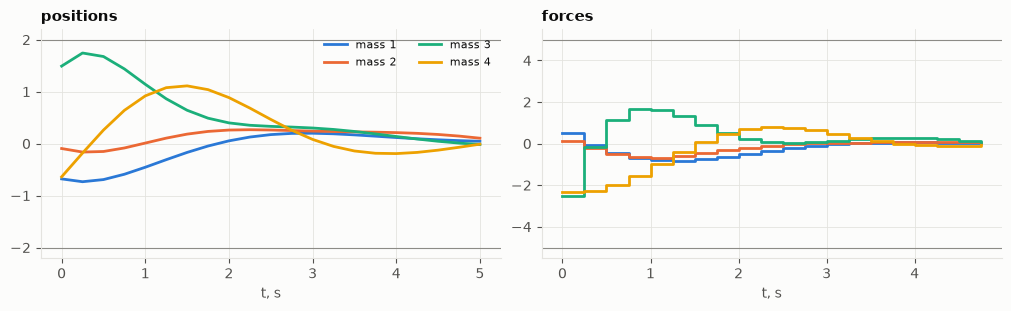

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.0))
t = masses.DT * np.arange(T + 1)
for i in range(4):
  axes[0].plot(t, xs[:, i], label=f"mass {i + 1}")
  axes[1].step(t[:-1], u[:, i], where="post")
for ax, bound in ((axes[0], masses.X_MAX), (axes[1], masses.U_MAX)):
  ax.axhline(bound, color=plotstyle.NEUTRAL, linewidth=0.8)
  ax.axhline(-bound, color=plotstyle.NEUTRAL, linewidth=0.8)
  ax.set_xlabel("t, s")
axes[0].set_title("positions")
axes[1].set_title("forces")
axes[0].legend(fontsize=8, ncol=2)
plt.show()

## What the generated solver costs to build and carry

The generated solver is one C function with no library behind it. Its workspace grows with the square
of the problem here: with $Q$ and $R$ as parameters, the objective Hessian is assembled as a dense
$n \times n$ array before its diagonal is read back (`internal/todo.md`, CS-12).

In [4]:
for horizon in (8, 16, 32):
  g = sc.opt.solver(masses.problem(horizon), sc.opt.IPM(options=options), name=f"nb_ws_T{horizon}")
  module = render_c_module(g)
  n = 4 * horizon + 8 * (horizon + 1)
  print(f"T = {horizon:>2}: {n:>4} variables, {len(module.body) / 1e3:>6.0f} kB of C, workspace {module.workspace_size:>7,} doubles (n^2 = {n * n:,})")

T =  8:  104 variables,    337 kB of C, workspace  29,066 doubles (n^2 = 10,816)
T = 16:  200 variables,    546 kB of C, workspace  81,954 doubles (n^2 = 40,000)
T = 32:  392 variables,    860 kB of C, workspace 242,755 doubles (n^2 = 153,664)


## The LDLᵀ microbenchmark

QOCO's Appendix B factors the KKT matrix of an LQR problem (6 states, 3 inputs, horizon $T$, random
$A$ and $B$, $Q = R = I$), $K = \begin{bmatrix} P & H^\top \\ H & -\varepsilon I\end{bmatrix}$ of order
$15T - 3$. Its script is not public; `ldl_bench.py` rebuilds the matrix from the description. The
pattern at $T = 15$ and its factor under Scaly's ordering:

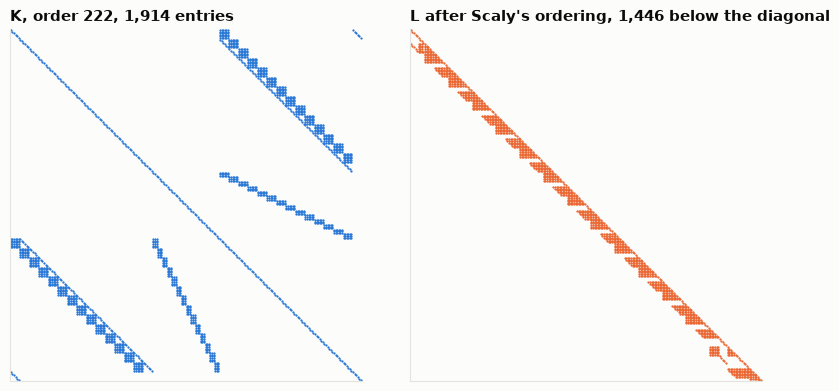

In [5]:
P, H = ldl_bench.lqr(15)
k_up = ldl_bench.kkt_upper(P, H)
from scaly.linalg.symbolic import analyze

rows, cols = sparse.coo_array(k_up).coords
sym = analyze(k_up.shape, np.asarray(rows), np.asarray(cols), "auto")
full = (k_up + sparse.triu(k_up, k=1).T).toarray() != 0
L = np.zeros(k_up.shape, dtype=bool)
for j in range(sym.n):
  L[sym.l_rows[sym.l_ptr[j] : sym.l_ptr[j + 1]], j] = True
fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))
axes[0].spy(full, markersize=0.6, color=plotstyle.BLUE)
axes[0].set_title(f"K, order {k_up.shape[0]}, {int(full.sum()):,} entries")
axes[1].spy(L | np.eye(sym.n, dtype=bool), markersize=0.6, color=plotstyle.ORANGE)
axes[1].set_title(f"L after Scaly's ordering, {sym.nnz_l:,} below the diagonal")
for ax in axes:
  ax.set_xticks([])
  ax.set_yticks([])
plt.show()

Scaly's factorization of that matrix, generated, compiled and timed here from C: with loops over the
analysis' tables (the default above `sparse_unroll`) and written out straight-line, as QOCOGEN writes
its factorization.

In [6]:
for schedule in ("auto", "unroll"):
  r = ldl_bench.run_scaly(k_up, None, Path(tempfile.mkdtemp(prefix="nb-ldl-")), schedule=schedule)
  print(f"{schedule:>6}: {r['factor_ns'] / 1e3:.2f} µs per factorization, {r['text_bytes'] / 1e3:.1f} kB of machine code, generated and compiled in {r['t_generate'] + r['t_compile']:.2f} s")

  auto: 3.61 µs per factorization, 2.1 kB of machine code, generated and compiled in 0.09 s


unroll: 1.28 µs per factorization, 82.1 kB of machine code, generated and compiled in 5.82 s


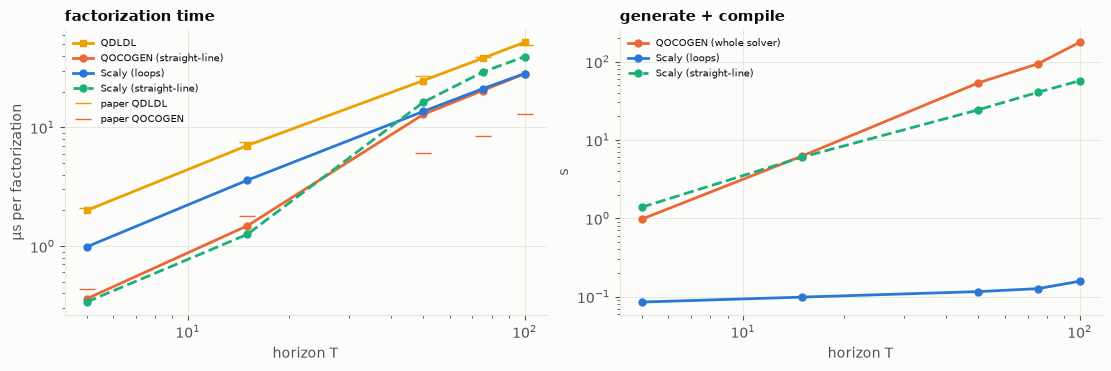

In [7]:
if RUN_BASELINES:
  subprocess.run(["sh", str(HERE / "baseline" / "setup.sh")], check=True)
  subprocess.run([*UV, str(HERE / "ldl_bench.py"), "--out", str(RESULTS / "ldl.json")], check=True)
ldl = json.loads((RESULTS / "ldl.json").read_text())
hs = [r["horizon"] for r in ldl]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for key, label, style, color in [
  ("qdldl", "QDLDL", "-s", plotstyle.YELLOW),
  ("qocogen", "QOCOGEN (straight-line)", "-o", plotstyle.ORANGE),
  ("scaly_own", "Scaly (loops)", "-o", plotstyle.BLUE),
  ("scaly_unroll", "Scaly (straight-line)", "--o", plotstyle.AQUA),
]:
  axes[0].plot(hs, [r[key]["factor_ns"] / 1e3 for r in ldl], style, color=color, label=label)
axes[0].plot(hs, [r["paper_us"][0] for r in ldl], "_", color=plotstyle.YELLOW, markersize=12, label="paper QDLDL")
axes[0].plot(hs, [r["paper_us"][1] for r in ldl], "_", color=plotstyle.ORANGE, markersize=12, label="paper QOCOGEN")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("horizon T")
axes[0].set_ylabel("µs per factorization")
axes[0].set_title("factorization time")
axes[0].legend(fontsize=7)
axes[1].plot(hs, [r["qocogen"]["t_generate"] + r["qocogen"]["t_compile"] for r in ldl], "-o", color=plotstyle.ORANGE, label="QOCOGEN (whole solver)")
axes[1].plot(hs, [r["scaly_own"]["t_generate"] + r["scaly_own"]["t_compile"] for r in ldl], "-o", color=plotstyle.BLUE, label="Scaly (loops)")
axes[1].plot(hs, [r["scaly_unroll"]["t_generate"] + r["scaly_unroll"]["t_compile"] for r in ldl], "--o", color=plotstyle.AQUA, label="Scaly (straight-line)")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("horizon T")
axes[1].set_ylabel("s")
axes[1].set_title("generate + compile")
axes[1].legend(fontsize=7)
plt.show()

## The whole solve, across horizons

`compare.py` solves five instances per horizon with every solver, in fresh processes: QOCOGEN
(generated from the horizon's first instance, `update_data` plus `qoco_custom_solve` inside the timer,
compiled with Scaly's flags), QOCO, Clarabel, OSQP at 1e-7 and at 1e-3, Scaly's generated PIQP and
the PIQP library, all at tolerance 1e-7 unless stated. The benchmark itself generates QOCOGEN only up
to horizon 56; here it is tried until one generation and compile exceeds 30 minutes.

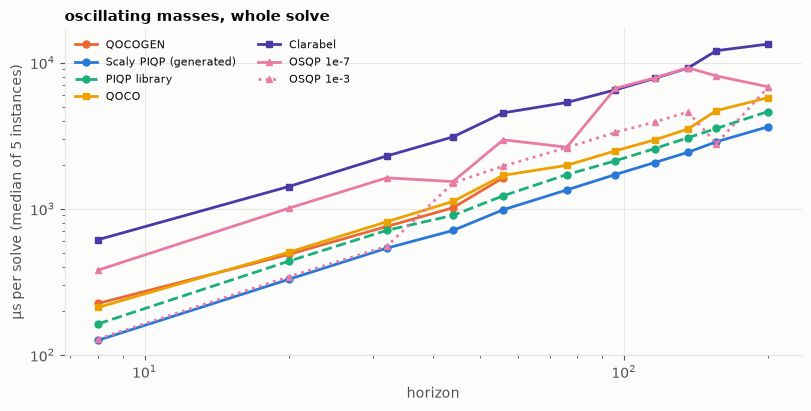

| Horizon | Variables | QOCOGEN, µs | Scaly PIQP (generated), µs | PIQP library, µs | QOCO, µs | Clarabel, µs | OSQP 1e-7, µs | OSQP 1e-3, µs |
| ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| 8 | 104 | 225.0 | 126.0 | 163.0 | 211.3 | 614.1 | 380.3 | 128.7 |
| 20 | 248 | 487.0 | 329.0 | 438.0 | 504.1 | 1418.6 | 1008.5 | 343.2 |
| 32 | 392 | 756.0 | 537.0 | 711.0 | 814.4 | 2293.8 | 1626.5 | 552.8 |
| 44 | 536 | 1015.0 | 710.0 | 901.0 | 1121.3 | 3099.3 | 1533.2 | 1501.3 |
| 56 | 680 | 1627.0 | 984.0 | 1226.0 | 1692.5 | 4526.2 | 2960.9 | 1957.6 |
| 76 | 920 | – | 1344.0 | 1711.0 | 1979.5 | 5328.8 | 2636.5 | 2618.5 |
| 96 | 1160 | – | 1713.0 | 2126.0 | 2488.3 | 6502.6 | 6662.2 | 3328.0 |
| 116 | 1400 | – | 2070.0 | 2579.0 | 2957.8 | 7795.7 | 7853.3 | 3919.6 |
| 136 | 1640 | – | 2430.0 | 3057.0 | 3510.9 | 9161.7 | 9204.8 | 4588.5 |
| 156 | 1880 | – | 2873.0 | 3542.0 | 4689.0 | 12054.3 | 8092.9 | 2789.2 |
| 200 | 2408 | – | 3636.0 | 4622.0 | 5754.8 | 13370.8 | 6825.2 | 6784

In [8]:
if RUN_BASELINES:
  subprocess.run([*UV, str(HERE / "compare.py"), "--out", str(RESULTS / "grid.json")], check=True)
grid = json.loads((RESULTS / "grid.json").read_text())
import importlib.util

# This study's compare.py; `compare` on the path is examples/opt/qp_solvers/compare.py, which ldl_bench uses.
_spec = importlib.util.spec_from_file_location("embedded_qp_compare", HERE / "compare.py")
grid_compare = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(grid_compare)

SOLVERS = [
  ("qocogen", "QOCOGEN", plotstyle.ORANGE, "-o"),
  ("scaly_sparse", "Scaly PIQP (generated)", plotstyle.BLUE, "-o"),
  ("piqp_sparse", "PIQP library", plotstyle.AQUA, "--o"),
  ("qoco", "QOCO", plotstyle.YELLOW, "-s"),
  ("clarabel", "Clarabel", plotstyle.VIOLET, "-s"),
  ("osqp", "OSQP 1e-7", plotstyle.MAGENTA, "-^"),
  ("osqp_1e-3", "OSQP 1e-3", plotstyle.MAGENTA, ":^"),
]
horizons = sorted(int(k) for k in grid)
summaries = {h: grid_compare.summary(grid[str(h)]) for h in horizons}
fig, ax = plt.subplots(figsize=(8, 4))
for key, label, color, style in SOLVERS:
  pts = [(h, summaries[h][key]) for h in horizons if key in summaries[h]]
  ax.plot([h for h, _ in pts], [v for _, v in pts], style, color=color, label=label)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("horizon")
ax.set_ylabel("µs per solve (median of 5 instances)")
ax.set_title("oscillating masses, whole solve")
ax.legend(fontsize=8, ncol=2)
plt.show()
print(grid_compare.table(grid))

## The embedded leg, sizes only

No board was attached, so this is what can be said without one: each generated solver compiled with
clang for a Cortex-M7 (`thumbv7em-none-eabihf -Os`), its flash (code and constants) and the RAM it
needs (its workspace; QOCOGEN's `Workspace` struct, Scaly's `w` array). The lines are an STM32F405
(1 MB flash, 192 kB RAM) and a Teensy 4.1 (8 MB flash, 1 MB RAM).

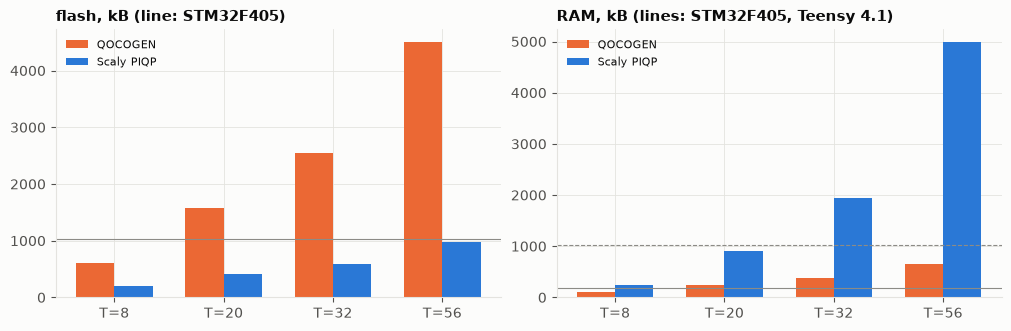

In [9]:
if RUN_BASELINES:
  subprocess.run([*UV, str(HERE / "embedded_size.py"), "--out", str(RESULTS / "embedded.json")], check=True)
emb = json.loads((RESULTS / "embedded.json").read_text())
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
he = np.arange(len(emb))
for i, (key, label, color) in enumerate([("qocogen", "QOCOGEN", plotstyle.ORANGE), ("scaly", "Scaly PIQP", plotstyle.BLUE)]):
  axes[0].bar(he + (i - 0.5) * 0.35, [r[key]["flash_bytes"] / 1e3 for r in emb], width=0.35, color=color, label=label)
  axes[1].bar(he + (i - 0.5) * 0.35, [r[key]["workspace_bytes"] / 1e3 for r in emb], width=0.35, color=color, label=label)
axes[0].axhline(1024, color=plotstyle.NEUTRAL, linewidth=0.8)
axes[1].axhline(192, color=plotstyle.NEUTRAL, linewidth=0.8)
axes[1].axhline(1024, color=plotstyle.NEUTRAL, linewidth=0.8, linestyle="--")
axes[0].set_title("flash, kB (line: STM32F405)")
axes[1].set_title("RAM, kB (lines: STM32F405, Teensy 4.1)")
for ax in axes:
  ax.set_xticks(he, [f"T={r['horizon']}" for r in emb])
  ax.legend(fontsize=8)
plt.show()

## What it shows

- **The factorization.** Scaly's straight-line `L D L'` beats QOCOGEN's at T = 5 and 15; its looped
  one matches QOCOGEN from T = 50, with 2 kB of machine code and a 0.1 s build against QOCOGEN's
  1.2 MB and 176 s. The loops are 1.9 to 2.1x QDLDL, the straight-line code up to 5.9x.
- **The whole solver.** Scaly's generated PIQP is the fastest of seven solvers at every horizon from
  8 to 200: 1.4 to 1.8x QOCOGEN, 1.2 to 1.3x the PIQP library it is generated from (the same
  iterations), 1.4 to 1.7x QOCO. Only OSQP at 1e-3 comes close, a thousand times less accurate.
- **Generation scales for Scaly and not for QOCOGEN.** QOCOGEN's generate plus compile grows from 15 s
  at T = 8 to 453 s at T = 56 and passes 40 minutes at T = 76. Scaly builds the T = 200 solver in
  5.4 s, with the same 50 kB of machine code as at T = 8.
- **Embedded.** Scaly's flash is a fifth to a third of QOCOGEN's, but its workspace is 2.4 to 7.7x
  larger and grows quadratically, because it builds the Hessian dense from the parameters (CS-12).
  Without that, it would fit an STM32F4 where QOCOGEN stops fitting.